imports and load dataset

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(
    "../data/insurance-data.csv",
    sep="|"
)

df.head()
plt.style.use("ggplot")
df.info()
df.describe()

C:\Users\raeye\AppData\Local\Temp\ipykernel_1924\2036456802.py:6: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


missing values

In [18]:

df.isnull().sum()

UnderwrittenCoverID               0
PolicyID                          0
TransactionMonth                  0
IsVATRegistered                   0
Citizenship                       0
LegalType                         0
Title                             0
Language                          0
Bank                         145961
AccountType                   40232
MaritalStatus                  8259
Gender                         9536
Country                           0
Province                          0
PostalCode                        0
MainCrestaZone                    0
SubCrestaZone                     0
ItemType                          0
mmcode                          552
VehicleType                     552
RegistrationYear                  0
make                            552
Model                           552
Cylinders                       552
cubiccapacity                   552
kilowatts                       552
bodytype                        552
NumberOfDoors               

loss ratio

In [19]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

df["LossRatio"].describe()

c:\Users\raeye\insurance-risk-analytics\venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


count    618614.0
mean          NaN
std           NaN
min          -inf
25%           0.0
50%           0.0
75%           0.0
max           inf
Name: LossRatio, dtype: float64

marigin

In [20]:
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

df["Margin"].head()

0     21.929825
1     21.929825
2      0.000000
3    512.848070
4      0.000000
Name: Margin, dtype: float64

Univariate Analysis
Histogram 

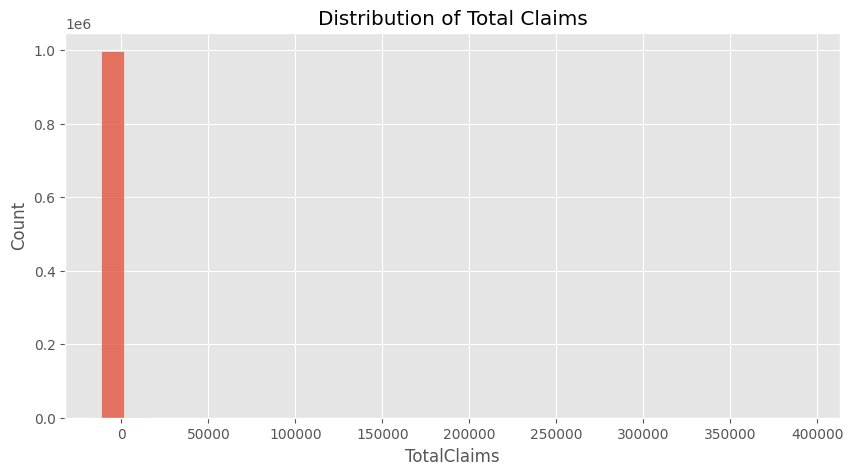

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df["TotalClaims"], bins=30)

plt.title("Distribution of Total Claims")

plt.show()

 Total Premium Histogram 

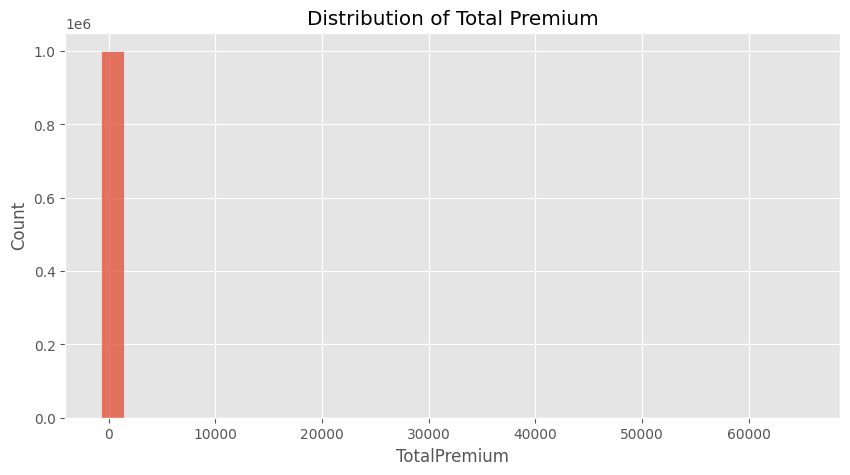

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(df["TotalPremium"], bins=30)

plt.title("Distribution of Total Premium")

plt.show()

Outlier Detection

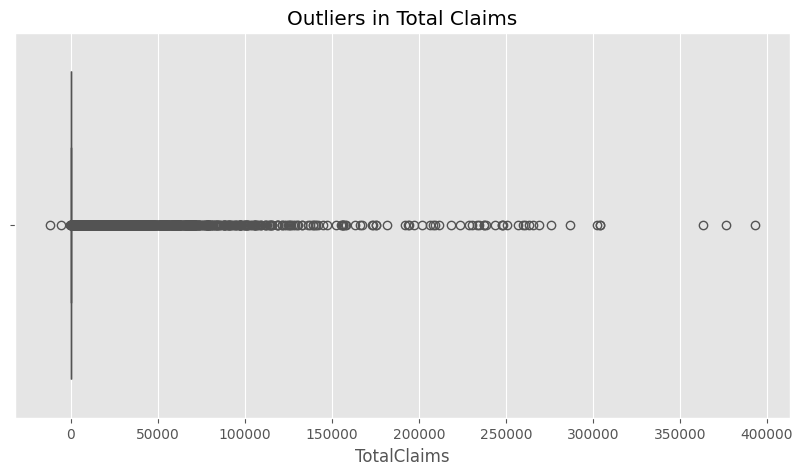

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["TotalClaims"])

plt.title("Outliers in Total Claims")

plt.show()

Province Analysis

c:\Users\raeye\insurance-risk-analytics\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\raeye\insurance-risk-analytics\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


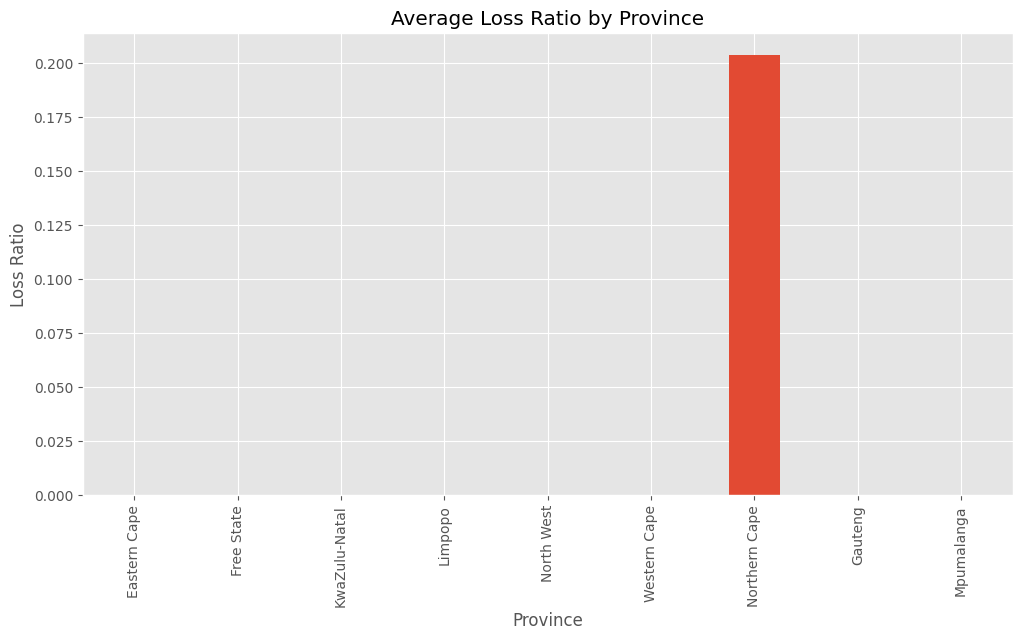

In [24]:
province_loss = df.groupby("Province")[
    "LossRatio"
].mean().sort_values(ascending=False)

province_loss
plt.figure(figsize=(12,6))

province_loss.plot(kind="bar")

plt.title("Average Loss Ratio by Province")

plt.ylabel("Loss Ratio")

plt.show()

Vehicle Type Analysis

In [25]:
vehicle_loss = df.groupby("VehicleType")[
    "LossRatio"
].mean().sort_values(ascending=False)

vehicle_loss

VehicleType
Bus                       inf
Heavy Commercial          inf
Medium Commercial         inf
Light Commercial     0.543917
Passenger Vehicle         NaN
Name: LossRatio, dtype: float64

Gender Analysis

In [26]:
gender_loss = df.groupby("Gender")[
    "LossRatio"
].mean()

gender_loss

Gender
Female           inf
Male             inf
Not specified    NaN
Name: LossRatio, dtype: float64

Correlation matrix

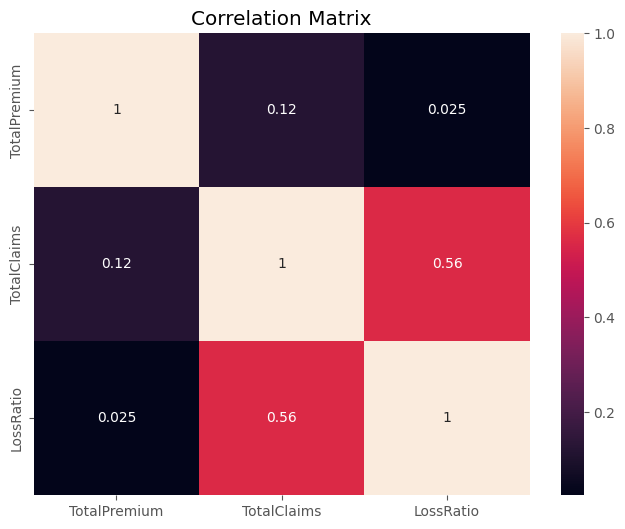

In [27]:
correlation = df[
    ["TotalPremium", "TotalClaims", "LossRatio"]
].corr()

correlation
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True)

plt.title("Correlation Matrix")

plt.show()

Temporal Trends

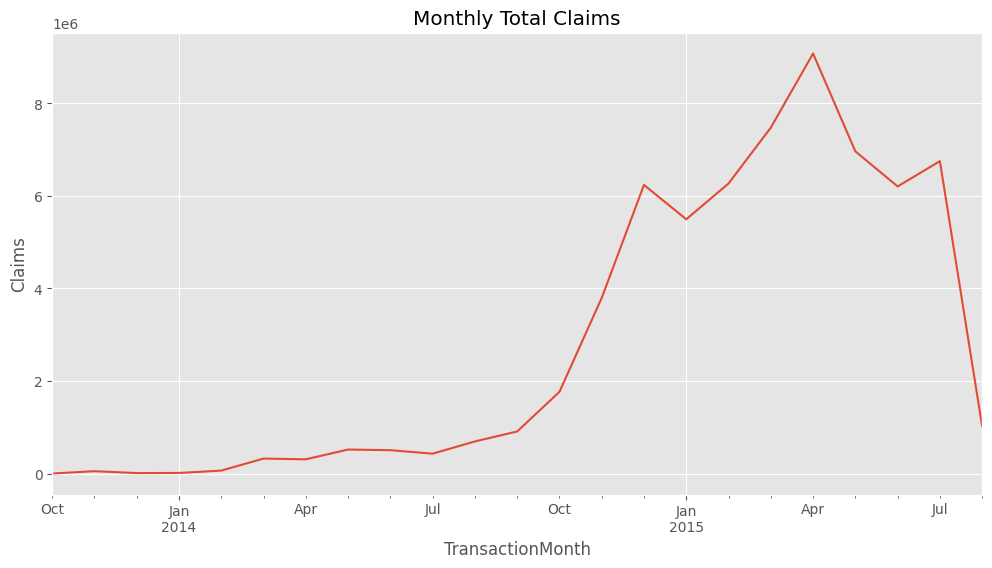

In [28]:
df["TransactionMonth"] = pd.to_datetime(
    df["TransactionMonth"]
)
monthly_claims = df.groupby(
    "TransactionMonth"
)["TotalClaims"].sum()

monthly_claims.plot(figsize=(12,6))

plt.title("Monthly Total Claims")

plt.ylabel("Claims")

plt.show()

Highest Claim Vehicle Makes

In [29]:
top_claims = df.groupby("Make")[
    "TotalClaims"
].mean().sort_values(ascending=False).head(10)

top_claims
plt.figure(figsize=(12,6))

top_claims.plot(kind="bar")

plt.title("Top Vehicle Makes by Average Claims")

plt.show()

KeyError: 'Make'